# 05_correct_emissivity

This notebook derives the surface properties required by the energy balance model and applies the emissivity correction to the thermal orthomosaics. It loads both thermal orthomosaics - one stitched from the uncalibrated images and one from the calibrated images (notebook 04) - together with the multispectral orthomosaic from the MicaSense Altum-PT. From these it derives NDVI, a water mask, per-class emissivity and albedo, the emissivity-corrected land surface temperature (LST), the land cover classification (LC) and canopy height, and stacks them into a single multi-band raster that feeds the OSEB model in notebook 06.

The multispectral orthomosaic was radiometrically processed with the `micasense/imageprocessing` library. TODO: reproduce it?

In [1]:
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
import os

from rasterio.mask import mask as rio_mask
from pyproj import Transformer
import warnings
warnings.filterwarnings("ignore")

In [2]:
from modules.utils import reproject_to_grid, fit_plane, read_tcp_utm, retrieve_canopy_height
from modules.ws import get_flight_tamb
from modules.emissivity import *

In [3]:
DATE = "20250807"
#DATES = ['20250622', '20250807', '20250813', '20250814']

ORTHO_DIR = "data/ortho"
WEATHER_DIR = "data/ancillary/weather"
COORDS_DIR = "data/ancillary/coords"

FIG_DIR = "results/05_correct_emissivity/figures"
os.makedirs(FIG_DIR, exist_ok=True)

OUT_DIR = "results/05_correct_emissivity/stacks"
os.makedirs(OUT_DIR, exist_ok=True)

aoi = gpd.read_file("data/ancillary/aoi.shp")

### Load and align the orthomosaics

Each orthomosaic is clipped to the area of interest (AOI), and the calibrated thermal and multispectral mosaics are resampled onto the uncalibrated thermal grid so that every derived layer is aligned. The `scene` mask keeps the pixels valid in both thermal mosaics; the very hot pixels (> 50 °C; the calibration plates) are then removed so they do not interfere with the surface maps.

In [6]:
src_thermal_raw = rio.open(f"{ORTHO_DIR}/therm_ortho_raw.tif")
src_thermal_corrected = rio.open(f"{ORTHO_DIR}/therm_ortho_corrected.tif")
src_multispectral = rio.open(f"{ORTHO_DIR}/ms_ortho_altumpt.tif")

tb_uncal, transform_ref = rio_mask(src_thermal_raw, aoi.geometry, crop=True, filled=True, nodata=np.nan)
tb_uncal = tb_uncal[0].astype("float32")
arr, tf = rio_mask(src_thermal_corrected, aoi.geometry, crop=True, filled=True, nodata=np.nan)
tb_cal = reproject_to_grid(arr[0].astype("float32"), tf, src_thermal_corrected.crs, tb_uncal.shape, transform_ref, src_thermal_raw.crs)
arr, tf = rio_mask(src_multispectral, aoi.geometry, crop=True, filled=True, nodata=np.nan)
msa = reproject_to_grid(arr.astype("float32"), tf, src_multispectral.crs, tb_uncal.shape, transform_ref, src_thermal_raw.crs)

scene = np.isfinite(tb_uncal) & np.isfinite(tb_cal)

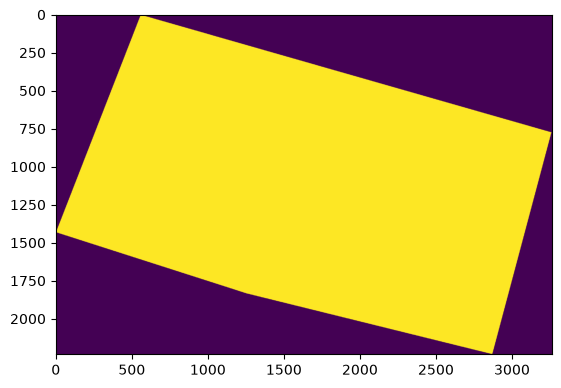

In [7]:
plt.imshow(scene)

In [8]:
tcp_mask = tb_uncal > 50 #leave out super hot pixels

scene = scene & ~tcp_mask

for a in (tb_uncal, tb_cal): 
    a[~scene] = np.nan

msa[:, ~scene] = np.nan
print("scene pixels: {}; TCP pixels masked: {}".format(scene.sum(), tcp_mask.sum()))

scene pixels: 4469193; TCP pixels masked: 885


### NDVI

NDVI is computed from the red and near-infrared bands of the multispectral orthomosaic. It is used both to separate the LC classes and to assign their emissivities. (In this orthomosaic produced using ODM the band order is Red = 0, Blue = 2, NIR = 3.)

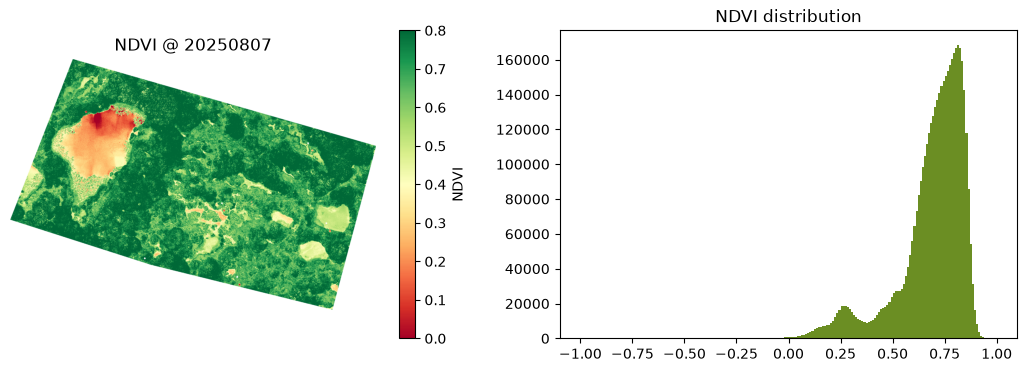

In [10]:
ndvi = (msa[3] - msa[0]) / (msa[3] + msa[0] + 1e-6)
ndvi = np.where(scene, np.clip(ndvi, -1, 1), np.nan).astype("float32")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(ndvi, cmap="RdYlGn", vmin=0, vmax=0.8)
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], label="NDVI")
ax[0].set_title(f"NDVI @ {DATE}")
ax[1].hist(ndvi[np.isfinite(ndvi)].ravel(), bins=200, color="olivedrab")
ax[1].set_title("NDVI distribution")
fig.savefig(f"{FIG_DIR}/{DATE}_ndvi.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

### Water mask

Because NDVI cannot reliably isolate open water here (thesis, Section 6.2), water is delineated with a normalised blue-red difference, `(B − R) / (B + R)`, thresholded and eroded to remove noise.

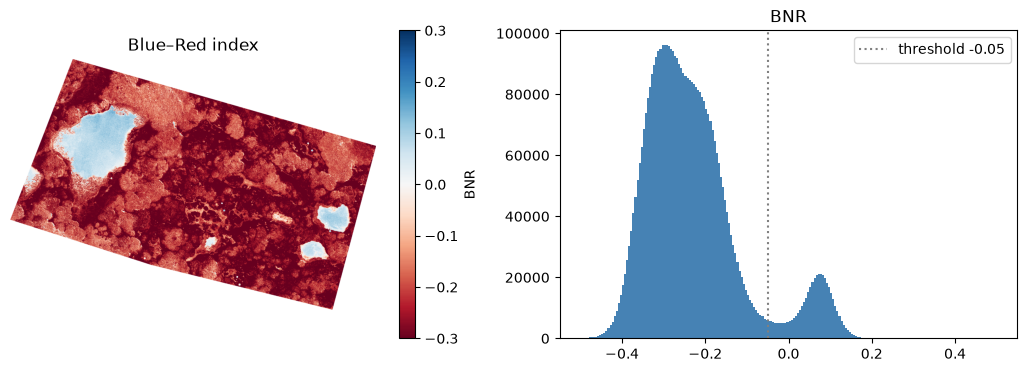

In [11]:
B, R = msa[2], msa[0]
bnr = np.where(scene, (B - R +1e-6) / (B + R + 1e-6), np.nan)

THRESHOLD_BR = -0.05
water_mask, _ = water_mask_from_bnr(msa, threshold=THRESHOLD_BR)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(bnr, cmap="RdBu", vmin=-0.3, vmax=0.3)
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], label="BNR")
ax[0].set_title("Blue–Red index")
ax[1].hist(bnr[np.isfinite(bnr)].ravel(), bins=200, color="steelblue", range=(-0.5,0.5))
ax[1].axvline(THRESHOLD_BR, color="grey", ls=":", label=f"threshold {THRESHOLD_BR}")
ax[1].legend()
ax[1].set_title("BNR")
fig.savefig(f"{FIG_DIR}/{DATE}_water.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

### Emissivity map

Emissivity is assigned per LC class rather than as a continuous NDVI-derived product. The classes are separated by NDVI thresholds as following: bare peat below 0.4, dwarf pine at or above 0.75, waterlogged peat in between. The open water is taken from the water mask. Each class is given an emissivity taken from the literature: 0.96 (bare peat), 0.97 (waterlogged peat), 0.98 (dwarf pine) and 0.99 (water) (based on Snyder et al. 1998).

In [12]:
EPS_BARE_PEAT, EPS_WATERLOGGED, EPS_DWARF_PINE, EPS_WATER = 0.96, 0.97, 0.98, 0.99

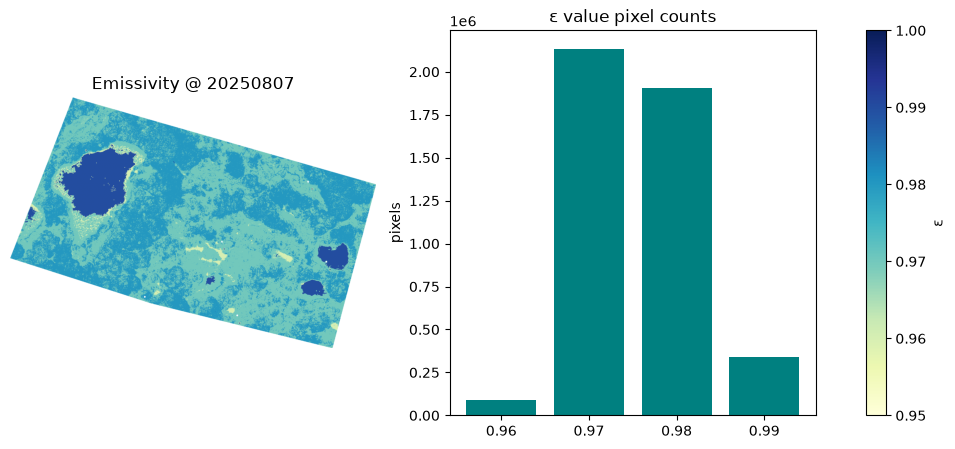

ε classes: {np.float32(0.96): np.int64(87714), np.float32(0.97): np.int64(2134134), np.float32(0.98): np.int64(1908406), np.float32(0.99): np.int64(338939)}


In [13]:
emissivity = np.where(scene, EPS_WATERLOGGED, np.nan).astype("float32")
emissivity[scene & (ndvi >= 0.75)] = EPS_DWARF_PINE
emissivity[scene & (ndvi <= 0.4)] = EPS_BARE_PEAT
emissivity[water_mask] = EPS_WATER

fig, ax = plt.subplots(1,2, figsize = (13,5))
im = ax[0].imshow(emissivity, cmap="YlGnBu", vmin=0.95, vmax=1)
ax[0].axis("off")
plt.colorbar(im, ax=ax, label="ε")
ax[0].set_title(f"Emissivity @ {DATE}")
vals, counts = np.unique(emissivity[np.isfinite(emissivity)].round(3), return_counts=True)
ax[1].bar([str(v) for v in vals], counts, color="teal")
ax[1].set_title("ε value pixel counts")
ax[1].set_ylabel("pixels")
fig.savefig(f"{FIG_DIR}/{DATE}_emissivity.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

print("ε classes:", {k: v for k, v in zip(vals, counts)})

### Effect of the emissivity correction

The per-class emissivity is propagated through the LST retrieval (Eq. 17 in thesis), and the difference between the emissivity-corrected LST and the brightness temperature shows how much the correction actually moves the surface temperature. It is expected to be small over this site.

T_amb 14.0°C   flagged 34 pixels > 50°C


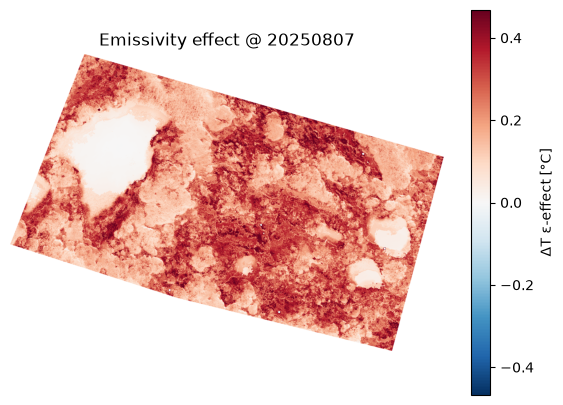

ε-effect on LST: median 0.20816993713378906°C, p99 0.4675884246826172°C


In [14]:
t_amb_c, t_amb_k, time_start, time_end = get_flight_tamb(DATE)
lst_cal = correct_brightness_to_lst(tb_cal, emissivity, t_amb_k)
lst_uncal = correct_brightness_to_lst(tb_uncal, emissivity, t_amb_k)
n_hot = int(np.nansum(lst_cal > 50))
for a in (lst_cal, lst_uncal): 
    a[a > 50] = np.nan
print(f"T_amb {t_amb_c:.1f}°C   flagged {n_hot} pixels > {50}°C")

eps_dT = lst_cal - tb_cal
dl = np.nanpercentile(np.abs(eps_dT[np.isfinite(eps_dT)]), 99)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(eps_dT, cmap="RdBu_r", vmin=-dl, vmax=dl)
ax.axis("off")
plt.colorbar(im, ax=ax, label="ΔT ε-effect [°C]")
ax.set_title(f"Emissivity effect @ {DATE}")
fig.savefig(f"{FIG_DIR}/{DATE}_emis_effect.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()
print("ε-effect on LST: median {}°C, p99 {}°C".format(np.nanmedian(np.abs(eps_dT)), dl))

## Canopy height

Canopy height is retrieved from the DSM. Because the DTM failed to generate (thesis, Section 4.2.5), the terrain is approximated by a plane fitted through the surveyed ground-level TCPs and subtracted from the DSM. TCP 3 is excluded because it sat on top of a dwarf pine rather than on the ground.

TODO: replace DSM

In [15]:
dsm_src = rio.open(f"{ORTHO_DIR}/dsm.tif")

arr_dsm, t_dsm = rio_mask(dsm_src, aoi.geometry, crop=True, filled=True, nodata=np.nan)

dsm = reproject_to_grid(arr_dsm[0].astype("float32"), t_dsm, dsm_src.crs, tb_uncal.shape, transform_ref, src_thermal_raw.crs)

In [16]:
TF_SJTSK_UTM = Transformer.from_crs('EPSG:5514', 'EPSG:32633', always_xy=True)

coords = read_tcp_utm(f"{COORDS_DIR}/20250807ur_sjtsk_tcp.csv", TF_SJTSK_UTM) #hardcoded, one DSM used
coords = coords[coords.tcp != 'tcp3'] # this one was positioned on top of dwarf pine, thus excluded

dtm_artificial = fit_plane(coords, transform_ref, dsm.shape)
#g = dtm_artificial[np.isfinite(dtm_artificial)] #
ch = retrieve_canopy_height(dsm, dtm_artificial)
ch[water_mask] = np.nan

Ground plane: 5 points used, RMSE 0.03710211409878409 m


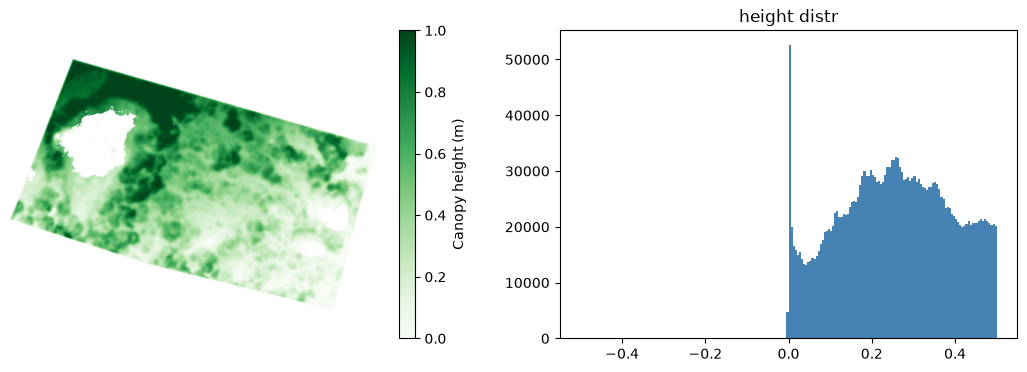

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(ch, cmap="Greens", vmin=0, vmax=1)
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], label="Canopy height (m)")
ax[1].hist(ch[np.isfinite(ch)].ravel(), bins=200, color="steelblue", range=(-0.5,0.5))
ax[1].set_title("height distr")
fig.savefig(f"{FIG_DIR}/canopy_height.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

### Land cover classes

The emissivity map is collapsed into discrete LC classes (1 = waterlogged peat, 2 = dwarf pine, 3 = bare peat, 4 = water).

LC pixel counts (1 waterlogged peat,2 dwarf pine,3 bare peat,4 water): {1: 2134134, 2: 1908406, 3: 87714, 4: 338939}


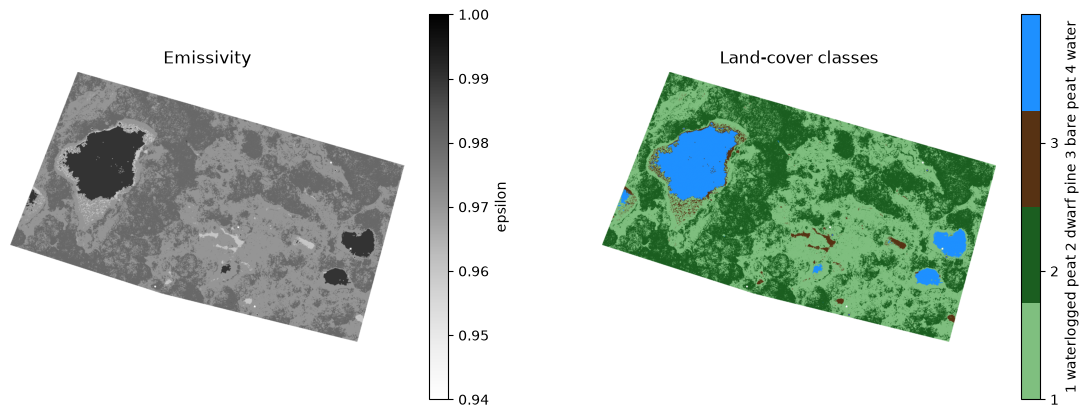

In [18]:
lc = np.full(scene.shape, np.nan, dtype="float32")
lc[emissivity == EPS_WATERLOGGED] = 1
lc[emissivity == EPS_DWARF_PINE] = 2
lc[emissivity == EPS_BARE_PEAT] = 3
lc[water_mask] = 4
print("LC pixel counts (1 waterlogged peat,2 dwarf pine,3 bare peat,4 water):",
      {int(k): int((lc==k).sum()) for k in (1,2,3,4)})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
im = ax[0].imshow(emissivity, cmap="Grays", vmin=0.94, vmax=1)
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], label="epsilon")
ax[0].set_title("Emissivity")
from matplotlib.colors import ListedColormap
im2 = ax[1].imshow(lc, cmap=ListedColormap(["#7fbf7f","#1b5e20","#573213","#1E90FF"]), vmin=1, vmax=4)
ax[1].axis("off")
ax[1].set_title("Land-cover classes")
plt.colorbar(im2, ax=ax[1], ticks=[1,2,3], label="1 waterlogged peat 2 dwarf pine 3 bare peat 4 water")
fig.savefig(f"{FIG_DIR}/{DATE}_landcover.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

### Albedo

A broadband albedo is assigned per LC class from literature values: 0.08 (bare peat), 0.15 (waterlogged peat), 0.11 (dwarf pine) and 0.06 (water).

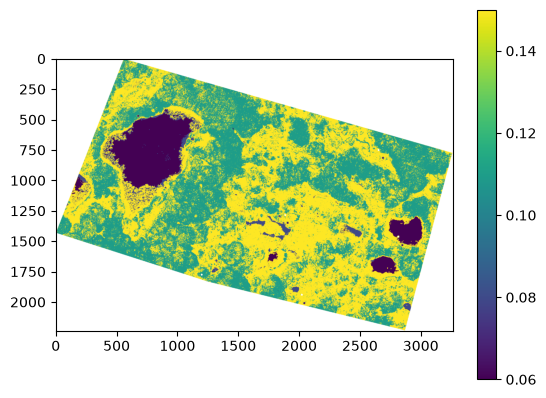

In [19]:
albedo = np.full(scene.shape, np.nan, dtype="float32")
albedo[(emissivity == EPS_WATERLOGGED)] = 0.15
albedo[(emissivity == EPS_DWARF_PINE)] = 0.11
albedo[(emissivity == EPS_BARE_PEAT)] = 0.08
albedo[water_mask] = 0.06
plt.imshow(albedo)
plt.colorbar()

## Build the model input stack

Finally, the derived layers are stacked into a single multi-band GeoTIFF on the common grid: emissivity, calibrated LST, uncalibrated brightness temperature, albedo, canopy height, water mask and LC class. This is the input to the OSEB model in notebook 06.

In [20]:
bands = [("emissivity", emissivity), ("lst_cal", lst_cal), ("tb_uncal", tb_uncal),
         ("albedo", albedo), ("canopy_height", ch), ("water_mask", water_mask.astype("float32")), ("lc", lc)]

stack = np.stack([b for _, b in bands]).astype("float32")

profile = {"driver":"GTiff", "height":stack.shape[1], "width":stack.shape[2], "count":stack.shape[0],
               "dtype":"float32", "crs":src_thermal_raw.crs, "transform":transform_ref, "nodata":np.nan, "compress":"lzw"}
out_path = f"{OUT_DIR}/{DATE}_stack.tif"
with rio.open(out_path, "w", **profile) as dst:
    dst.write(stack)
    for i, (nm, _) in enumerate(bands, 1):
        dst.set_band_description(i, nm)
print(f"wrote {out_path} ({len(bands)} bands: {[n for n,_ in bands]})")

wrote results/05_correct_emissivity/stacks/20250807_stack.tif (7 bands: ['emissivity', 'lst_cal', 'tb_uncal', 'albedo', 'canopy_height', 'water_mask', 'lc'])
